# Exploratory Data Analysis

**OULAD Student Clustering · ENSIA · Spring 2025–2026**

We explore `master_raw.csv` before feature engineering. We do **not** change any rows — only inspect tables and draw figures. The goal is to understand outcome balance, VLE engagement, assessment behaviour, demographics, and differences between modules.


## Key terms 

| Term | Meaning in this project |
|------|-------------------------|
| **Registration** | One row in `master_raw.csv`: a student (`id_student`) enrolled on one **module presentation**. A student can appear on several rows if they took several modules. |
| **Cohort** | All registrations that share the same **`code_module`** and **`code_presentation`**. Example: **BBB-2014J** is the cohort “module BBB, presentation starting 2014J”. It is **not** a cluster from machine learning — it is just a course run. |
| **Module** | Course code in OULAD (**AAA** … **GGG**). Seven modules in our table. |
| **Presentation** | When that module was offered (**2013J**, **2014J**, etc.). **J** = February start, **B** = October start. |
| **Outcome / `final_result`** | Label after the course: **Pass**, **Fail**, **Withdrawn**, or **Distinction**. We use it to **describe** patterns in EDA; clustering in later notebooks does **not** use it as an input. |
| **VLE engagement** | Virtual Learning Environment activity: clicks, active days, weekly clicks, activity types (quiz / forum / resource). |
| **Missing submission rate** | Share of due assessments not submitted: `total_missing / total_assessments_due`. |
| **Submission delay** | Days relative to the deadline (negative = submitted early). |


---
> ###  Critical Rule — `final_result` Is Never a Model Input
>
> Throughout this EDA we use `final_result` (Pass / Fail / Withdrawn / Distinction) to **describe** and **understand** behavioral patterns. We compare click volumes, submission rates, and engagement across outcome groups to motivate feature choices.
>
> **`final_result` never enters the feature matrix X** that goes into clustering. Clustering in notebook 03 is fully unsupervised — the algorithm receives only the 17 behavioral features from notebook 02. `final_result` is used only **after** clustering, to check whether the discovered groups align with actual outcomes .
---


## 1. Setup


In [91]:
%matplotlib inline

import sys
from pathlib import Path

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import seaborn as sns
from IPython.display import display

ROOT = Path("..").resolve()
if str(ROOT) not in sys.path:
    sys.path.insert(0, str(ROOT))

# Force reload so Jupyter picks up the latest eda_plots.py (not a cached old version)
import importlib

import src.eda_plots as eda_plots
importlib.reload(eda_plots)

from src.eda_plots import (
    EDA_PLOTS_VERSION,
    RESULT_ORDER,
    add_missing_rate,
    plot_active_days_distribution,
    plot_activity_type_by_outcome,
    plot_click_distribution,
    plot_clicks_by_outcome,
    plot_cohort_registrations,
    plot_correlation_matrix,
    plot_demographics_by_outcome,
    plot_disengagement_by_outcome,
    plot_engagement_scatter,
    plot_missing_rate_by_outcome,
    plot_module_comparison,
    plot_result_distribution,
    plot_score_distribution_by_outcome,
    plot_submission_delay_by_outcome,
    plot_temporal_heatmap,
)

assert hasattr(eda_plots, "plot_activity_type_by_outcome"), (
    "src/eda_plots.py is outdated — pull latest or restart kernel after saving the file."
)
print(f"eda_plots loaded: v{EDA_PLOTS_VERSION} from {eda_plots.__file__}")

PROCESSED = ROOT / "data" / "processed"
FIGURES = ROOT / "figures" / "eda"
FIGURES.mkdir(parents=True, exist_ok=True)

plt.rcParams.update({
    "figure.dpi": 120,
    "figure.figsize": (10, 6),
    "font.family": "sans-serif",
    "axes.spines.top": False,
    "axes.spines.right": False,
})

sns.set_theme(style="whitegrid", font_scale=0.95)
print(f"Figures: {FIGURES}")


eda_plots loaded: v2.1 from D:\Ensia\3rd year\Afaf\S2\Machine Learning\project\src\eda_plots.py
Figures: D:\Ensia\3rd year\Afaf\S2\Machine Learning\project\figures\eda


## 2. Load and inspect `master_raw`


We load `data/processed/master_raw.csv` (**68 columns**, including `missing_rate` from notebook 00).

We print:

- row and column counts;
- how many values are missing in important columns;
- counts and percentages of each **`final_result`**;
- a small preview and numeric summary.

`add_missing_rate()` ensures `missing_rate` is present (same formula as notebook 00: `total_missing / total_assessments_due`). It does not reload raw CSV files.

Note: figure files saved to `figures/eda/` use numeric prefixes (`01_`, `02_`…) that match the plotting order, not the section numbers in this notebook.



In [92]:
master = pd.read_csv(PROCESSED / "master_raw.csv")
master = add_missing_rate(master)
n_anchor = len(master)

print(f"Shape: {master.shape[0]:,} rows × {master.shape[1]} columns")
print(f"Modules: {master['code_module'].nunique()} | Presentations: {master['code_presentation'].nunique()}")
print("\nMissing values (columns with any NaN):")
miss = master.isna().sum()
print(miss[miss > 0])

print("\nfinal_result:")
print(master["final_result"].value_counts())
print((master["final_result"].value_counts(normalize=True) * 100).round(1).astype(str) + "%")

display(master.head(8))
display(master.describe().T.head(16))


Shape: 32,593 rows × 68 columns
Modules: 7 | Presentations: 4

Missing values (columns with any NaN):
imd_band                 1111
date_registration          45
date_unregistration     22521
avg_submission_delay     7034
dtype: int64

final_result:
final_result
Pass           12361
Withdrawn      10156
Fail            7052
Distinction     3024
Name: count, dtype: int64
final_result
Pass           37.9%
Withdrawn      31.2%
Fail           21.6%
Distinction     9.3%
Name: proportion, dtype: object


,code_module,code_presentation,id_student,gender,region,highest_education,imd_band,age_band,num_of_prev_attempts,studied_credits,...,score_std,avg_submission_delay,late_submission_count,early_submission_count,avg_score,total_assessments_due,total_missing,clicks_per_day,active_day_rate,missing_rate
0,AAA,2013J,11391,M,East Anglian Region,HE Qualification,90-100%,55<=,0,240,...,3.082207,-1.8,0.0,0.0,82.4,5.0,0.0,3.485075,0.149254,0.0
1,AAA,2013J,28400,F,Scotland,HE Qualification,20-30%,35-55,0,60,...,4.335897,0.0,2.0,0.0,65.4,5.0,0.0,5.354478,0.298507,0.0
2,AAA,2013J,30268,F,North Western Region,A Level or Equivalent,30-40%,35-55,0,60,...,0.000000,NaN,0.0,0.0,0.0,0.0,0.0,1.048507,0.044776,0.0
3,AAA,2013J,31604,F,South East Region,A Level or Equivalent,50-60%,35-55,0,60,...,6.892024,-2.0,0.0,0.0,76.3,5.0,0.0,8.052239,0.458955,0.0
4,AAA,2013J,32885,F,West Midlands Region,Lower Than A Level,50-60%,0-35,0,60,...,20.513410,11.4,5.0,0.0,55.0,5.0,0.0,3.858209,0.261194,0.0
5,AAA,2013J,38053,M,Wales,A Level or Equivalent,80-90%,35-55,0,60,...,10.977249,2.0,1.0,0.0,66.9,5.0,0.0,9.123134,0.533582,0.0
6,AAA,2013J,45462,M,Scotland,HE Qualification,30-40%,0-35,0,60,...,4.949747,0.4,2.0,0.0,67.8,5.0,0.0,5.567164,0.335821,0.0
7,AAA,2013J,45642,F,North Western Region,A Level or Equivalent,90-100%,0-35,0,120,...,0.547723,2.6,2.0,0.0,72.5,5.0,0.0,5.328358,0.391791,0.0


,count,mean,std,min,25%,50%,75%,max
id_student,32593.0,706687.669131,549167.313855,3733.0,508573.0,590310.0,644453.0,2716795.0
num_of_prev_attempts,32593.0,0.163225,0.479758,0.0,0.0,0.0,0.0,6.0
studied_credits,32593.0,79.758691,41.071900,30.0,60.0,60.0,120.0,655.0
module_length,32593.0,256.010125,13.179078,234.0,241.0,262.0,268.0,269.0
date_registration,32548.0,-69.411300,49.260522,-322.0,-100.0,-57.0,-29.0,167.0
date_unregistration,10072.0,49.757645,82.460890,-365.0,-2.0,27.0,109.0,444.0
is_withdrawn,32593.0,0.309023,0.462098,0.0,0.0,0.0,1.0,1.0
total_clicks,32593.0,1215.141257,1692.604449,0.0,142.0,602.0,1585.0,24139.0
active_days,32593.0,55.475685,54.515290,0.0,11.0,40.0,85.0,286.0
first_access_day,32593.0,-7.375265,12.667962,-25.0,-17.0,-9.0,0.0,238.0


**Interpretation**

- **32,593 registrations** and **68 columns** in `master_raw.csv` (includes `missing_rate` saved in notebook 00).
- `avg_score` is filled with **0** for students who never submitted any graded work — so `avg_score = 0` means "no submissions recorded," not necessarily "scored zero." This is a deliberate imputation from notebook 00. In notebook 02, `weighted_avg_score` inherits this value, and `missing_submission_rate` separately captures whether the student actually submitted work, so the two features together distinguish "submitted and scored low" from "never submitted."
- `avg_submission_delay` stays **NaN** for non-submitters in `master_raw`; notebook 02 handles that when building `submission_timing`.
- Outcomes: **Pass 37.9%**, **Withdrawn 31.2%**, **Fail 21.6%**, **Distinction 9.3%** — a large at-risk share before feature engineering.


## 3. Cohort overview (module × presentation)



**What is a cohort here?** One **cohort** = one combination of **`code_module`** + **`code_presentation`** (e.g. **CCC-2014J**). Each bar is how many **student registrations** that cohort has.

we draw a bar chart of registration counts per cohort, sorted by size, to see which course runs are largest and smallest.


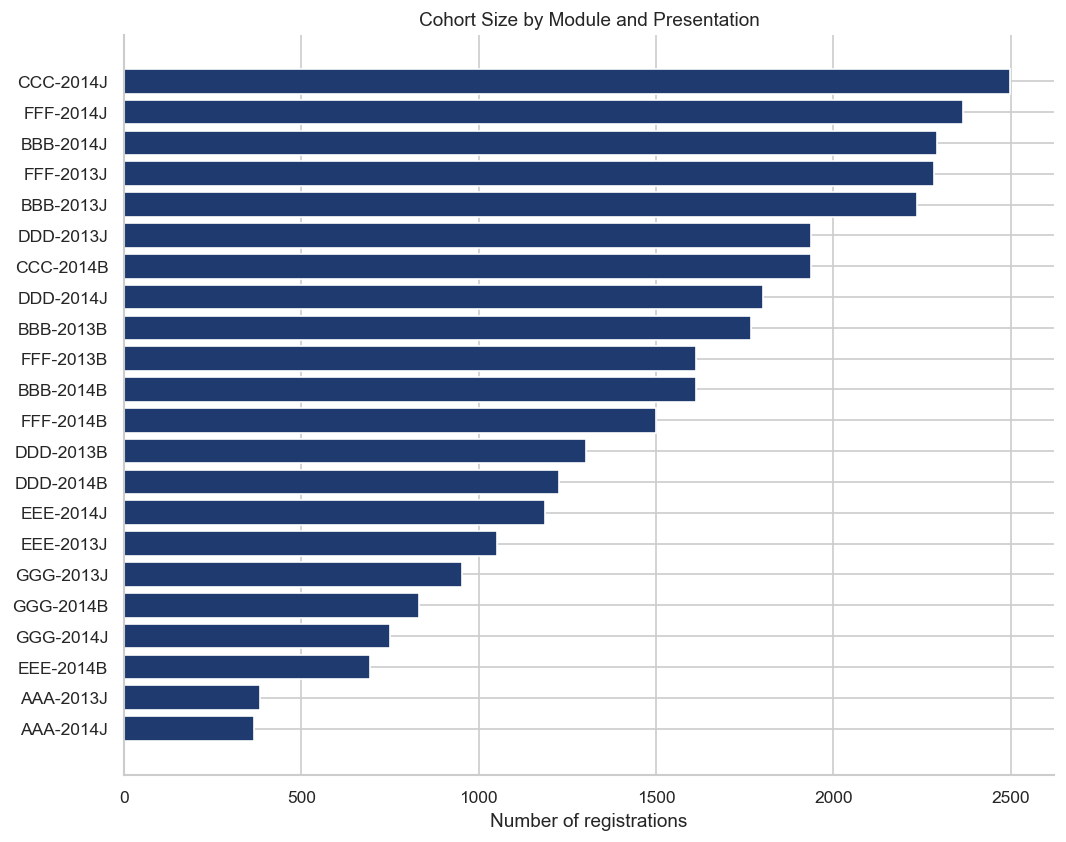

Saved and displayed: 02_cohort_registrations.png


In [93]:
saved_path = plot_cohort_registrations(master, FIGURES / "02_cohort_registrations.png", show=True)
print(f"Saved and displayed: {saved_path.name}")


**Interpretation**

- Largest cohorts: **CCC-2014J (2,498)**, **FFF-2014J (2,365)**, **BBB-2014J (2,292)**.
- Smallest: **AAA-2014J (365)**.
- Sizes vary a lot, so pooled statistics can hide presentation-level effects — normalizing by `module_length` in notebook 00 was appropriate.


## 4. Final result distribution



We plot a bar chart of how many registrations fall in each **`final_result`** category (Pass, Fail, Withdrawn, Distinction).


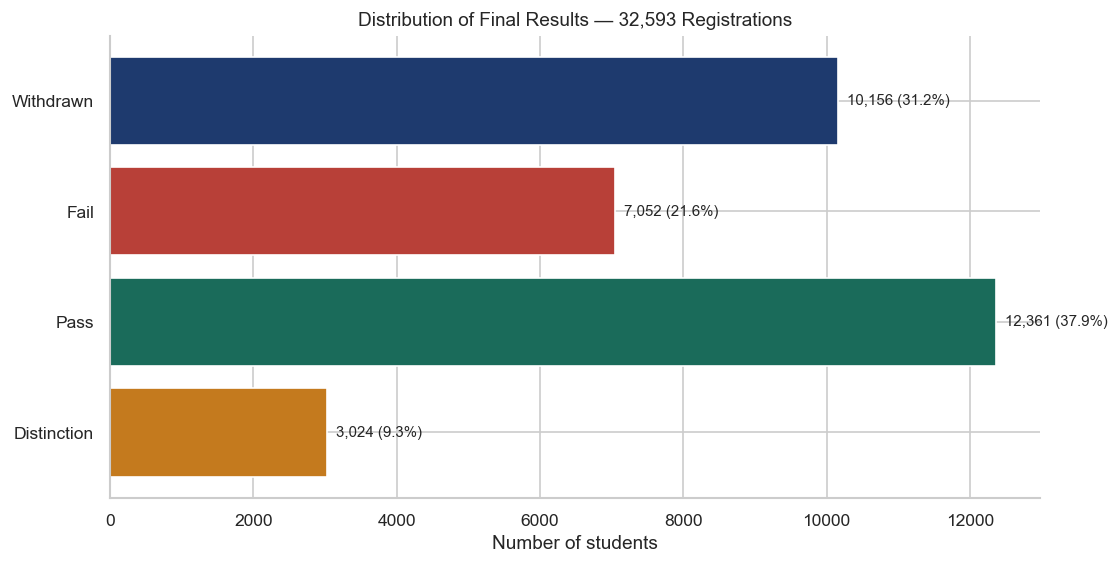

Saved and displayed: 01_final_result_distribution.png


In [94]:
saved_path = plot_result_distribution(master, FIGURES / "01_final_result_distribution.png", show=True)
print(f"Saved and displayed: {saved_path.name}")


**Interpretation**

- Roughly **one in three** students **withdraw** and **one in five** **fail**; **distinction** is under **10%**.
- **Withdrawn** is the second-largest group after **Pass**, so disengagement and non-submission matter as much as exam scores for this project.


## 5. VLE click volume (raw vs log)


We plot **two** histograms of **`total_clicks`**: raw counts (often very skewed) and **log(1 + clicks)** to see whether a log transform is reasonable for modelling.


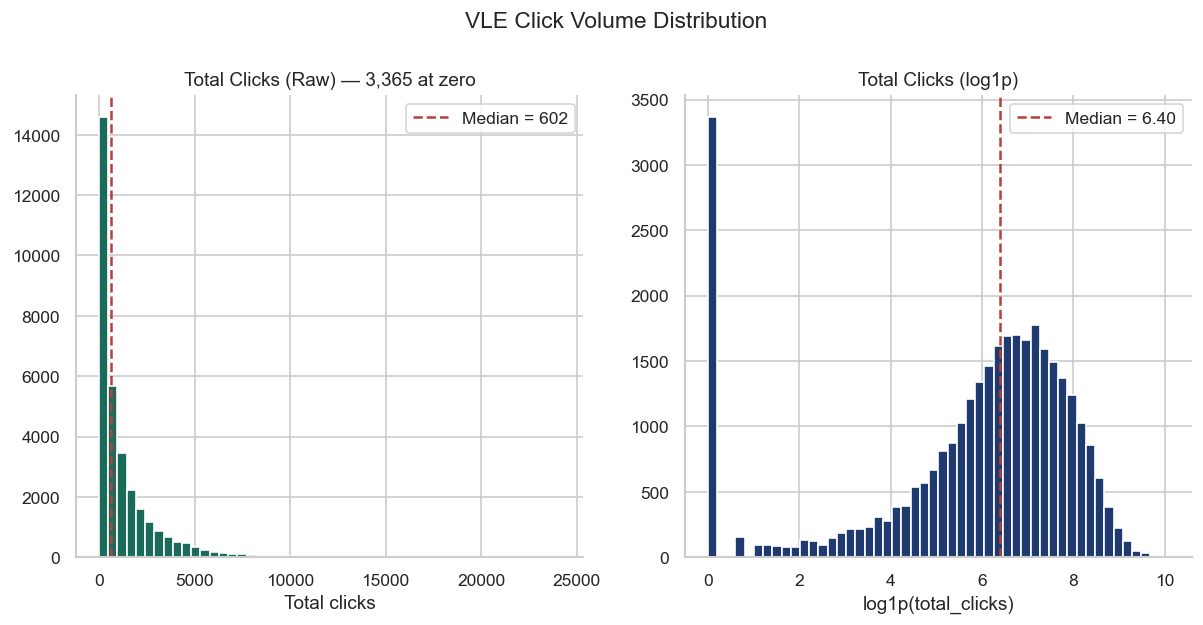

Saved and displayed: 03_click_distribution.png


In [95]:
saved_path = plot_click_distribution(master, FIGURES / "03_click_distribution.png", show=True)
print(f"Saved and displayed: {saved_path.name}")


**Interpretation**

- Raw distribution is extremely right-skewed; **3,365 students (10.3%)** have **zero** total clicks.
- The log panel is more symmetric → log transforms in notebook 02 are justified.
- Zero-click rows are real non-use of the VLE, not values to impute with the mean.


## 6. Total clicks by outcome


We compare **`total_clicks`** across **`final_result`** using a **boxplot** with a symlog y-axis (so low and high values are visible). We read median and spread per outcome.


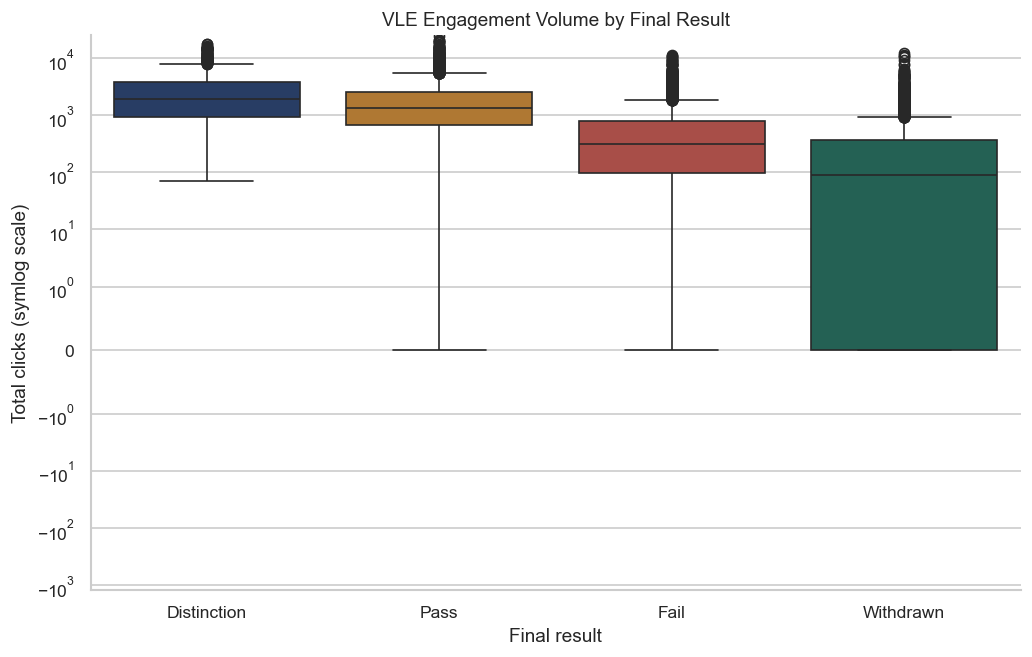

Saved and displayed: 04_clicks_by_outcome.png


In [96]:
saved_path = plot_clicks_by_outcome(master, FIGURES / "04_clicks_by_outcome.png", show=True)
print(f"Saved and displayed: {saved_path.name}")


**Interpretation**

- Mean **clicks per day** (from notebook 00): **Distinction 10.4**, **Pass 7.5**, **Fail 2.6**, **Withdrawn 1.2**.
- Boxes overlap, but **withdrawn** and **fail** sit clearly lower than **pass** and **distinction** — engagement volume already flags many at-risk students.


## 7. Active days


We plot the distribution of **`active_days`** (number of distinct days with at least one VLE click) for all registrations.


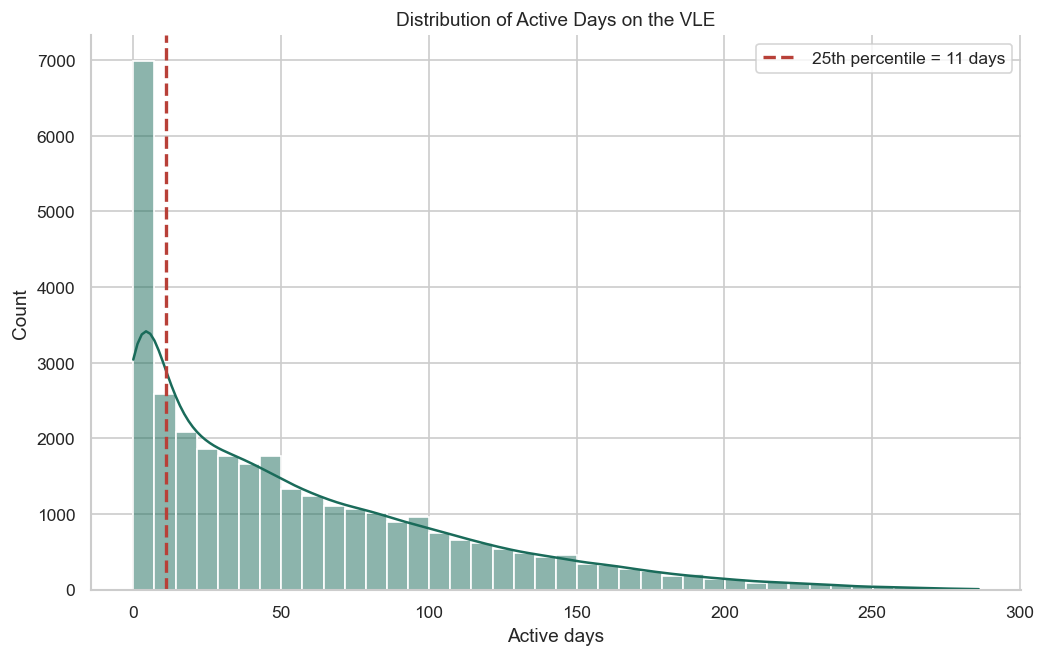

Saved and displayed: 05_active_days_distribution.png


In [97]:
saved_path = plot_active_days_distribution(master, FIGURES / "05_active_days_distribution.png", show=True)
print(f"Saved and displayed: {saved_path.name}")


**Interpretation**

- Median **40** active days; **25th percentile only 11** days.
- Mean active days by outcome: **Withdrawn 16**, **Fail 33**, **Pass 87**, **Distinction 110**.
- Low tail = sporadic or absent access; upper mass = sustained activity across the module.


## 8. Zero-click disengagement by outcome



For each **`final_result`**, we compute the **percentage of registrations with `total_clicks == 0`** and draw a bar chart.


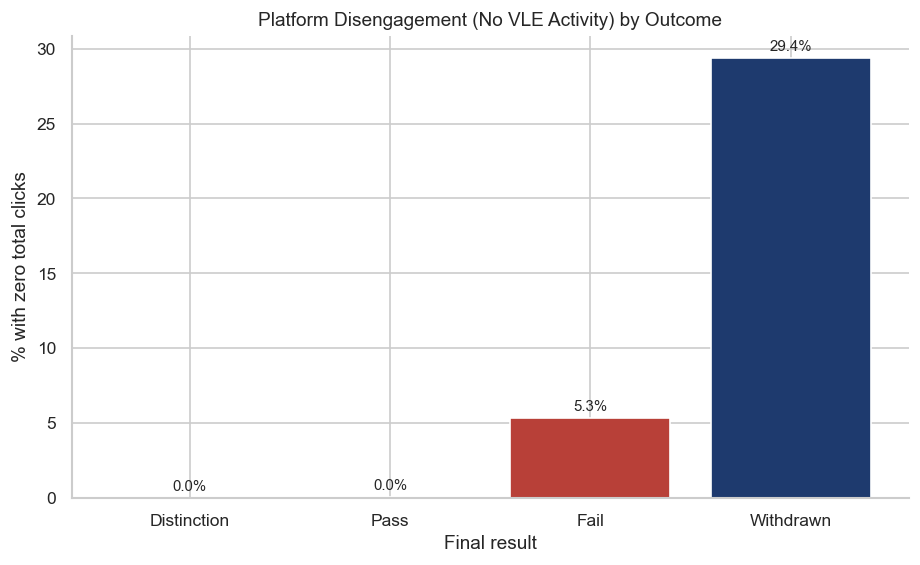

Saved and displayed: 06_disengagement_by_outcome.png


In [98]:
saved_path = plot_disengagement_by_outcome(master, FIGURES / "06_disengagement_by_outcome.png", show=True)
print(f"Saved and displayed: {saved_path.name}")


**Interpretation**

- **Distinction & pass:** **0%** zero-click.
- **Fail:** **5.3%** zero-click.
- **Withdrawn:** **29.4%** zero-click — by far the highest.
- Filling missing VLE values with **0** in notebook 00 correctly highlights disengaged students.


## 9. Engagement rate vs average score


We scatter **`clicks_per_day`** (x) against **`avg_score`** (y), coloured by **`final_result`**, for students with a defined average score.


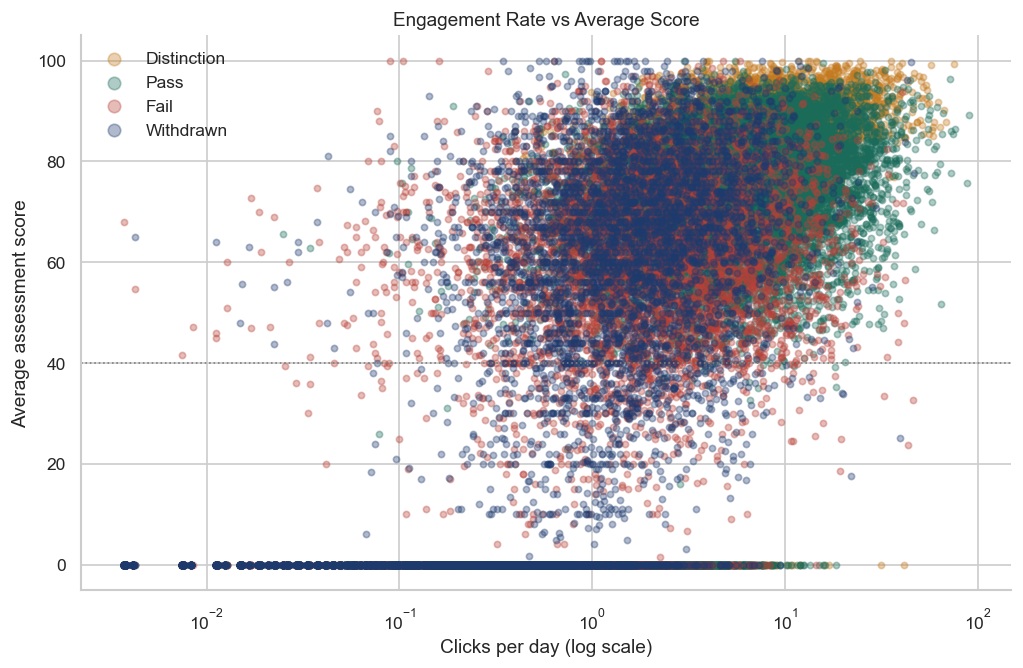

Saved and displayed: 07_engagement_vs_score.png


In [99]:
saved_path = plot_engagement_scatter(master, FIGURES / "07_engagement_vs_score.png", show=True)
print(f"Saved and displayed: {saved_path.name}")


**Interpretation**

- Higher **`clicks_per_day`** tends to go with higher **`avg_score`** (Pearson **r ≈ 0.48**), but the cloud is wide.
- **Withdrawn** points cluster bottom-left; some active students still score poorly.
- One feature alone will not separate everyone — we need the full feature set in notebook 02.


## 10. Activity type mix by outcome


We bar-chart mean **`quiz_clicks`**, **`forum_clicks`**, and **`resource_clicks`** per **`final_result`** to see whether active vs passive VLE use differs.


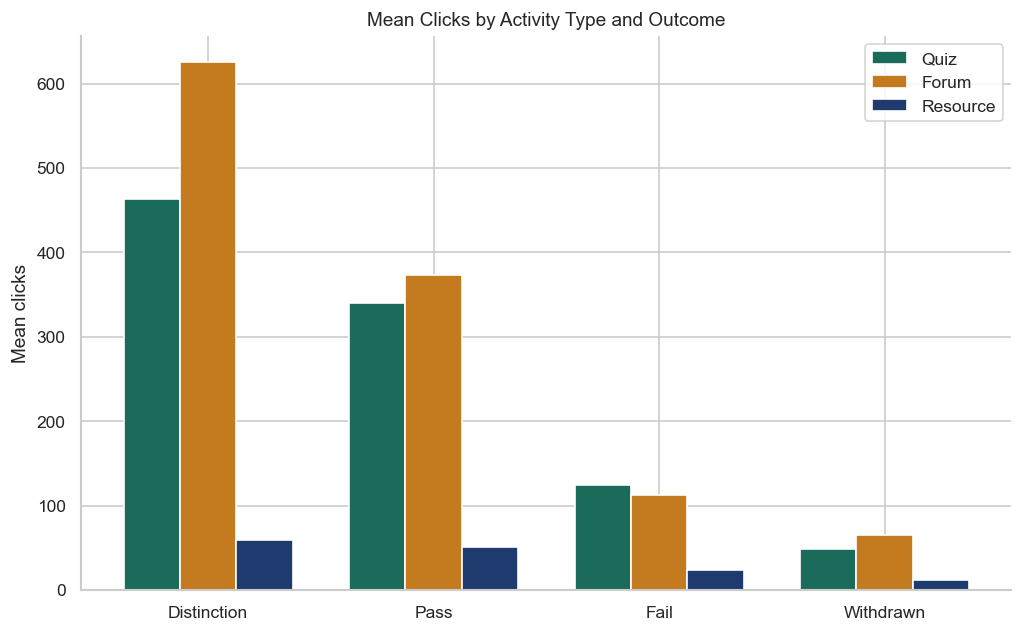

Saved and displayed: 12_activity_type_by_outcome.png


In [100]:
saved_path = plot_activity_type_by_outcome(master, FIGURES / "12_activity_type_by_outcome.png", show=True)
print(f"Saved and displayed: {saved_path.name}")


**Interpretation**

- Mean **quiz / forum** clicks: **Withdrawn 48 / 66** → **Distinction 463 / 625**.
- **Resource** clicks stay flatter (**13–59**).
- Quiz and forum (active learning) separate outcomes more than resources alone → motivates quiz/forum ratio features.


## 11. Missing submission rate


We boxplot **`missing_rate`** (= share of assessments not submitted) by **`final_result`**, with light points for a random sample of students.


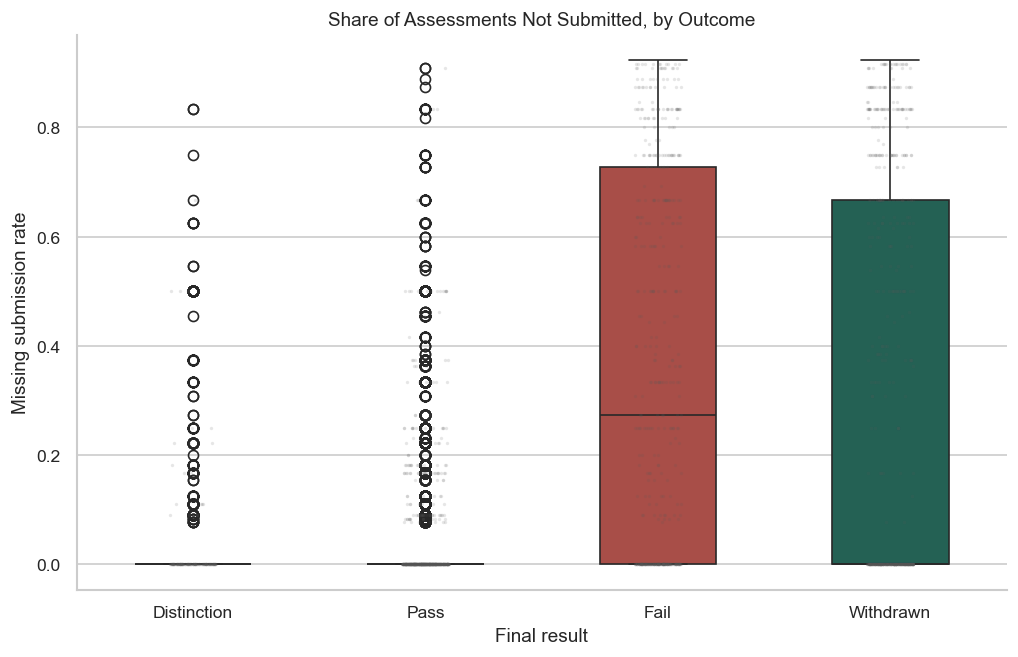

Saved and displayed: 08_missing_rate_by_outcome.png


In [101]:
saved_path = plot_missing_rate_by_outcome(master, FIGURES / "08_missing_rate_by_outcome.png", show=True)
print(f"Saved and displayed: {saved_path.name}")


**Interpretation**

- Mean missing rate: **Distinction 3.4%**, **Pass 4.7%**, **Fail 36.4%**, **Withdrawn 30.1%**.
- Medians: **0** for distinction, pass, and withdrawn; **0.27 for fail**.
- **Withdrawn** also has a heavy upper tail (75th percentile **67%** missing) despite median 0 — partial non-submission before leaving.
- Strong candidate feature for clustering.


## 12. Submission delay


We violin-plot **`avg_submission_delay`** (days vs deadline; **negative = early**) by **`final_result`**, with a dashed line at **0** (deadline).


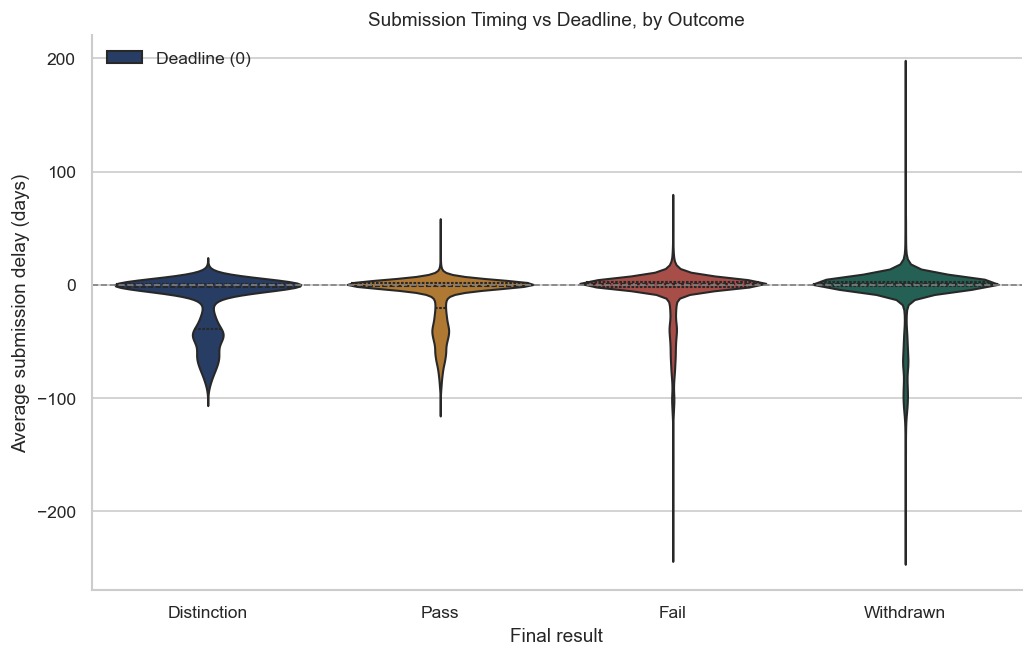

Saved and displayed: 09_submission_delay_by_outcome.png


In [102]:
saved_path = plot_submission_delay_by_outcome(master, FIGURES / "09_submission_delay_by_outcome.png", show=True)
print(f"Saved and displayed: {saved_path.name}")


**Interpretation**

- Mean delay: **Distinction −17.5 days**, **Pass −12.5**, **Fail −7.1**, **Withdrawn −6.6** (medians near **0 to −2**).
- **Distinction** students submit earliest on average; **fail/withdraw** closer to the deadline.
- Some **fail** students submit on time but still score poorly — punctuality ≠ performance.


## 13. Weekly engagement heatmap


We average each **`week_N_clicks`** column by **`final_result`** and draw a heatmap (rows = outcome, columns = week of module).


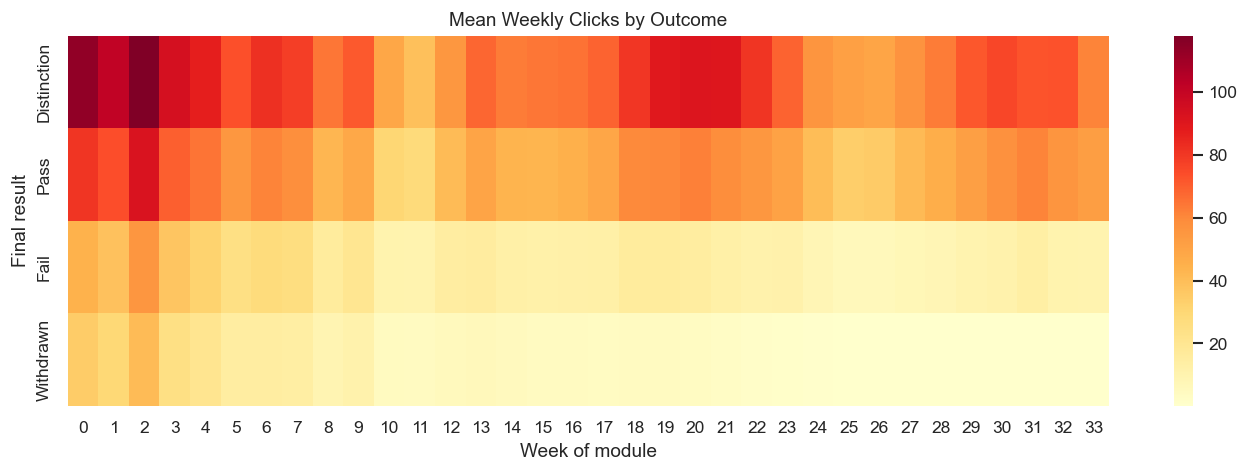

Saved and displayed: 10_temporal_heatmap.png


In [103]:
saved_path = plot_temporal_heatmap(master, FIGURES / "10_temporal_heatmap.png", show=True)
print(f"Saved and displayed: {saved_path.name}")


**Interpretation**

- **Distinction** and **Pass** stay relatively active across many weeks.
- **Withdrawn** activity collapses after mid-course (late-week mean **≈0.4** clicks vs **≈56** for **Pass**).
- Mid-course bright bands often match assessment periods; late spikes suggest deadline-driven **massed** engagement (Peach et al., 2019).
- Temporal features (`late_click_ratio`, weekly slopes) are well motivated.


## 14. Score distributions


we overlay **KDE curves** of **`avg_score`** per **`final_result`**, with a vertical line at **40** (common fail threshold in OULAD discussions).


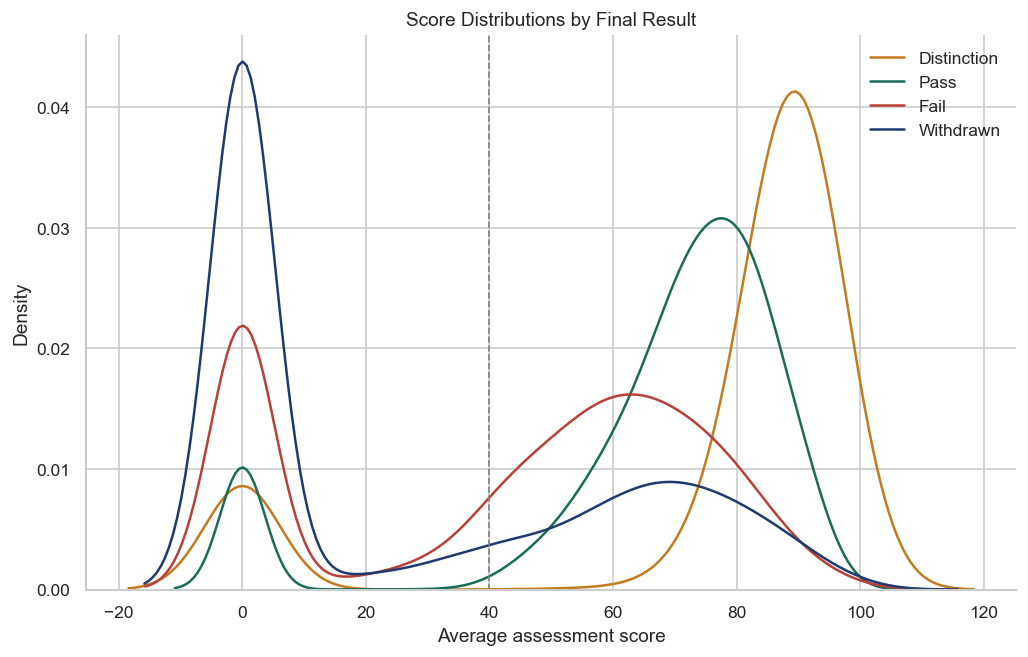

Saved and displayed: 11_score_distribution_by_outcome.png


In [104]:
saved_path = plot_score_distribution_by_outcome(master, FIGURES / "11_score_distribution_by_outcome.png", show=True)
print(f"Saved and displayed: {saved_path.name}")


**Interpretation**

- **Distinction** peaks high (mean **76.8**); **Pass** in the middle.
- **Fail** and **Withdrawn** overlap heavily below **40** (**35.5%** of fails and **63.5%** of withdrawn with scores below 40).
- **`avg_score`** alone cannot define clusters, but it helps **validate** behavioural clusters later.


## 15. Demographics vs outcome


we draw stacked bar charts crossing **`final_result`** with **`age_band`**, **`highest_education`**, **`gender`**, and **`num_of_prev_attempts`**

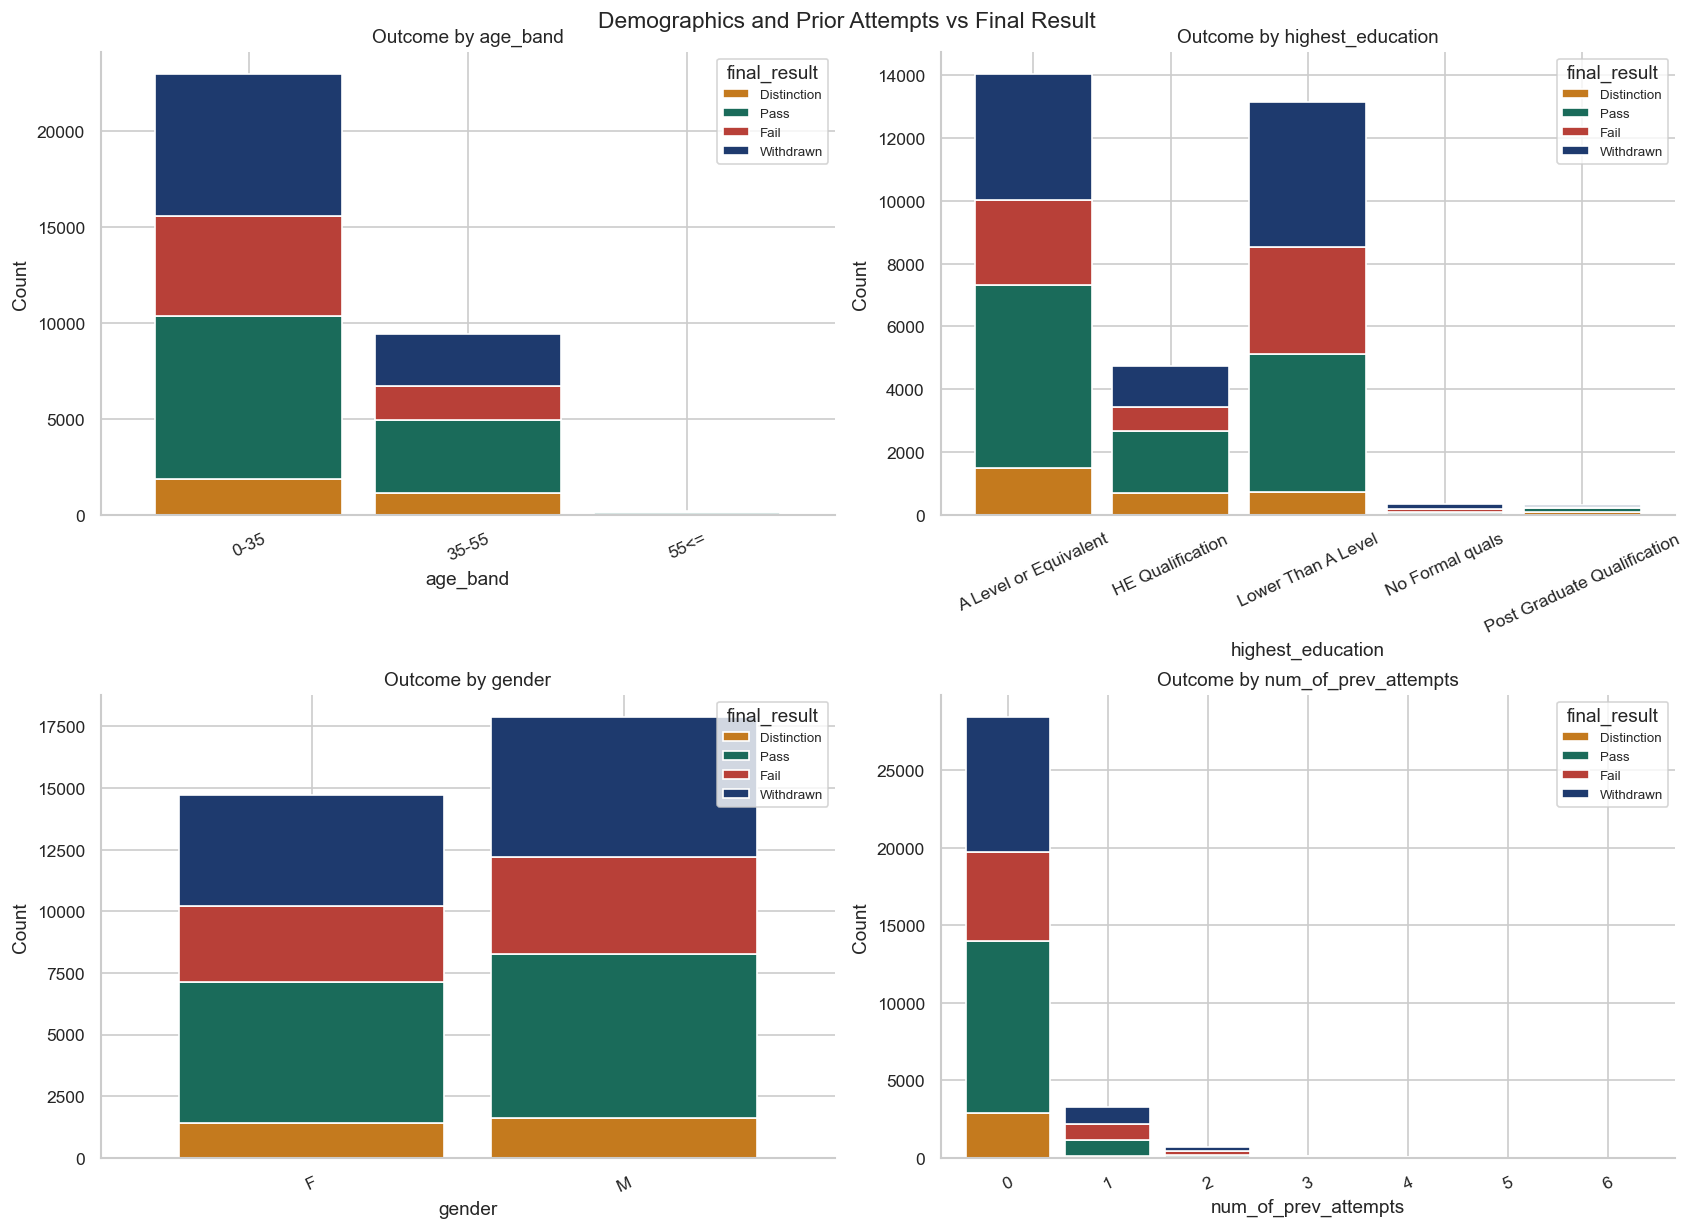

Saved and displayed: 13_demographics_by_outcome.png


In [105]:
saved_path = plot_demographics_by_outcome(master, FIGURES / "13_demographics_by_outcome.png", show=True)
print(f"Saved and displayed: {saved_path.name}")


**Interpretation**

- **Withdrawal rate** examples: age **0–35 → 31.9%** vs **55+ → 25.0%**; education **No Formal quals → 42.9%** vs **Post Graduate → 23.3%**.
- **Gender** mix is similar across outcomes (~**44–46%** female in each bar).
- Demographics describe **who** is in the data; clustering will use **behavioural** features only.


## 16. Correlation matrix


We heatmap Pearson correlations among numeric engagement and assessment columns (clicks, active days, rates, missing work, scores).


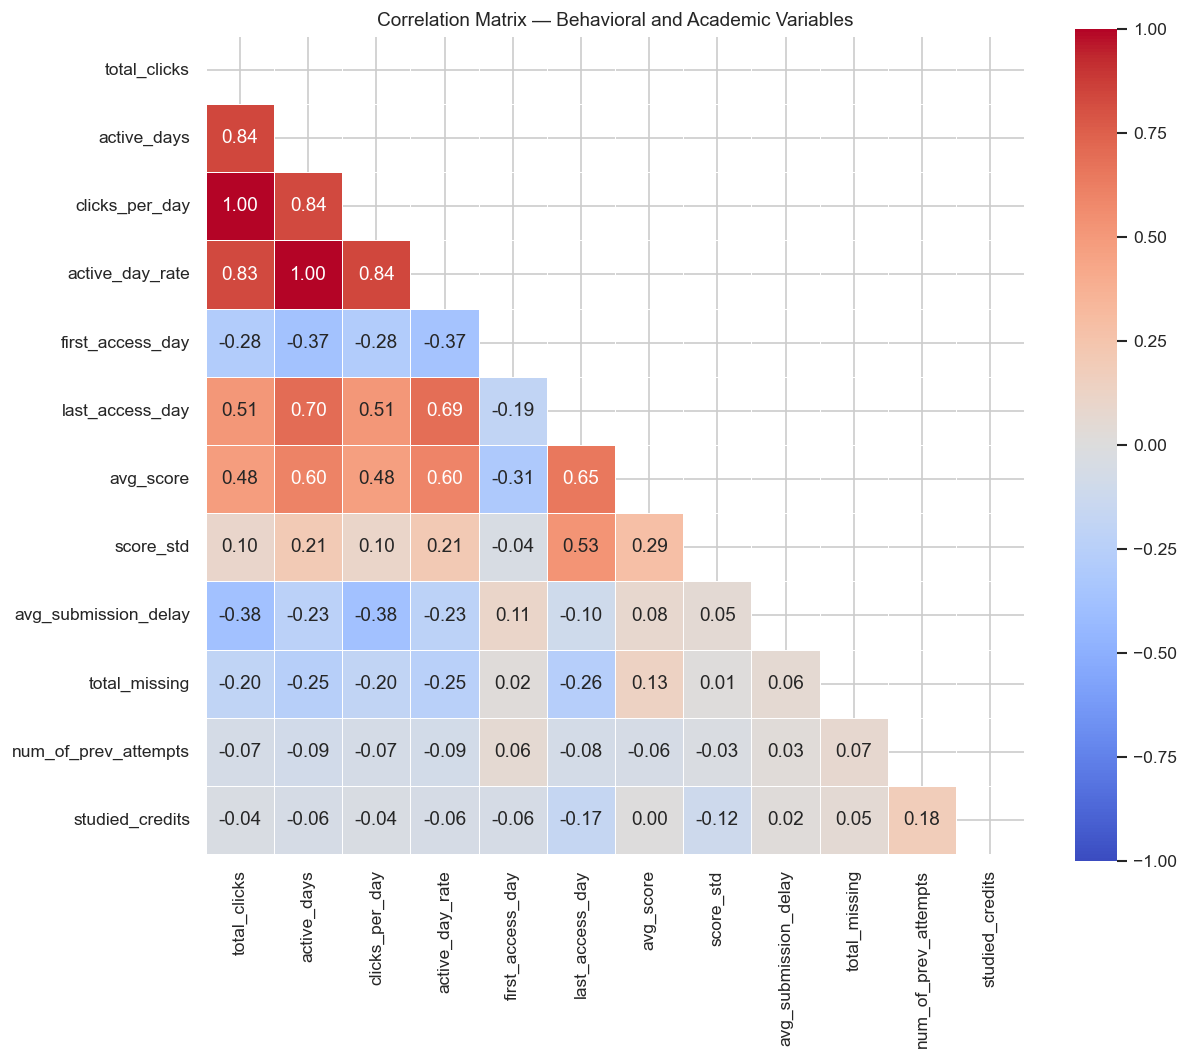

Saved and displayed: 14_correlation_matrix.png


In [106]:
saved_path = plot_correlation_matrix(master, FIGURES / "14_correlation_matrix.png", show=True)
print(f"Saved and displayed: {saved_path.name}")


**Interpretation**

- **total_clicks**, **active_days**, **clicks_per_day**, **active_day_rate** are highly correlated (**|r| ≈ 0.83–1.00**)
- **total_missing** aligns with worse outcomes in the plots; linear **r** with **avg_score** is only **≈ 0.13**.
- Plan for notebook 02: log transforms and drop redundant raw counts.


## 17. Module comparison


We compare **`code_module`** on **withdrawal rate** (`is_withdrawn`) and mean **`clicks_per_day`** (already normalized by module length).


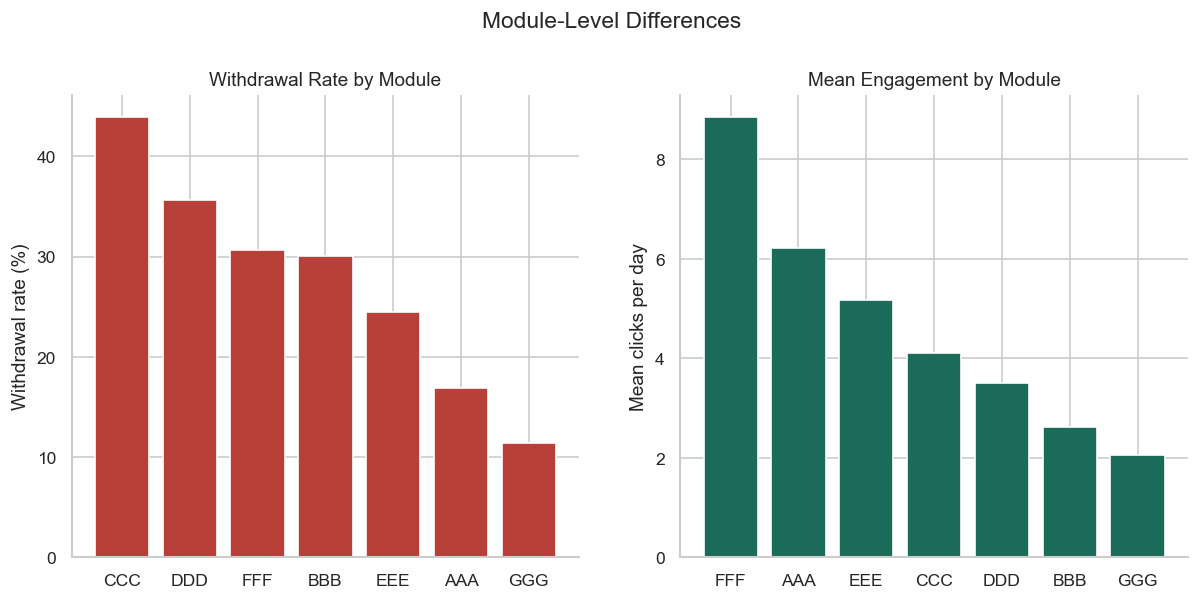

Saved and displayed: 15_module_comparison.png


In [107]:
saved_path = plot_module_comparison(master, FIGURES / "15_module_comparison.png", show=True)
print(f"Saved and displayed: {saved_path.name}")


**Interpretation**

- Highest withdrawal: **CCC 43.9%** (moderate **4.1** clicks/day).
- Lowest withdrawal: **GGG 11.4%**.
- **FFF**: high engagement (**8.8** clicks/day) but **30.7%** withdrawal — busy but not always successful.
- Module codes (AAA–GGG) differ in culture and length; rate features were necessary.


## 18. Summary table by outcome


We build a **numeric summary table**: group by **`final_result`** and aggregate key engagement and assessment metrics (means/medians as appropriate).


In [108]:
summary = (
    master.groupby("final_result", observed=True)
    .agg(
        count=("id_student", "count"),
        mean_avg_score=("avg_score", "mean"),
        mean_clicks_per_day=("clicks_per_day", "mean"),
        mean_active_day_rate=("active_day_rate", "mean"),
        mean_missing_rate=("missing_rate", "mean"),
        pct_zero_clicks=("total_clicks", lambda s: (s == 0).mean() * 100),
        median_submission_delay=("avg_submission_delay", "median"),
    )
    .reindex([x for x in RESULT_ORDER if x in master["final_result"].unique()])
)
display(summary.style.background_gradient(cmap="YlOrRd", axis=0).format(precision=2))



,count,mean_avg_score,mean_clicks_per_day,mean_active_day_rate,mean_missing_rate,pct_zero_clicks,median_submission_delay
final_result,,,,,,,
Distinction,3024,76.83,10.36,0.43,0.03,0.00,-2.00
Pass,12361,67.02,7.49,0.34,0.05,0.02,-0.88
Fail,7052,43.49,2.57,0.13,0.36,5.30,0.27
Withdrawn,10156,26.42,1.23,0.06,0.30,29.42,0.50


**Interpretation**

- Across **32,593** registrations: disengagement (**10.3%** zero-click overall; **29.4%** among withdrawn), high missing work for **fail**, and fading weekly activity for **withdrawn** line up with at-risk outcomes.
- **Distinction** combines high clicks/day, early submission, and low missing rates.
- Next step: notebook **02** — log/rate features, temporal slopes, submission metrics; keep **`final_result`** for post-hoc validation only.
